# Session 03: Image Filtering & Frequency Analysis

**CVI4IC — Summer Semester 2026**

Topics: convolution, Gaussian filter, border handling, Fourier transform, frequency-domain filtering, and hybrid images.

In [1]:
# !pip install -q opencv-python-headless matplotlib numpy scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
!git clone --depth 1 https://github.com/fruits-360/fruits-360-100x100.git 2>/dev/null || echo "Dataset already cloned."

DATASET_ROOT = Path("fruits-360-100x100")
TRAIN_DIR = DATASET_ROOT / "Training"
TEST_DIR = DATASET_ROOT / "Test"

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Fruits-360: {len(classes)} classes")

def load_fruit(class_name, index=0):
    """Load a single fruit image as BGR numpy array."""
    cls_dir = TRAIN_DIR / class_name
    return cv2.imread(str(sorted(cls_dir.glob("*.jpg"))[index]))

def to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def to_gray(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

Dataset already cloned.
Fruits-360: 258 classes


## 1. Convolution — The Core Operation

A **linear filter** (convolution) replaces each pixel with a weighted sum of its neighbours:

$$g(x, y) = \sum_{i=-k}^{k} \sum_{j=-k}^{k} h(i, j) \cdot f(x - i, y - j)$$

where $h$ is the **kernel** (filter mask) of size $(2k+1) \times (2k+1)$.

In OpenCV any kernel can be applied with `cv2.filter2D(img, -1, kernel)`.

### 1.1 Average (Box) Filter

The simplest filter: every weight is equal. Replaces each pixel with the **mean** of its neighbourhood.

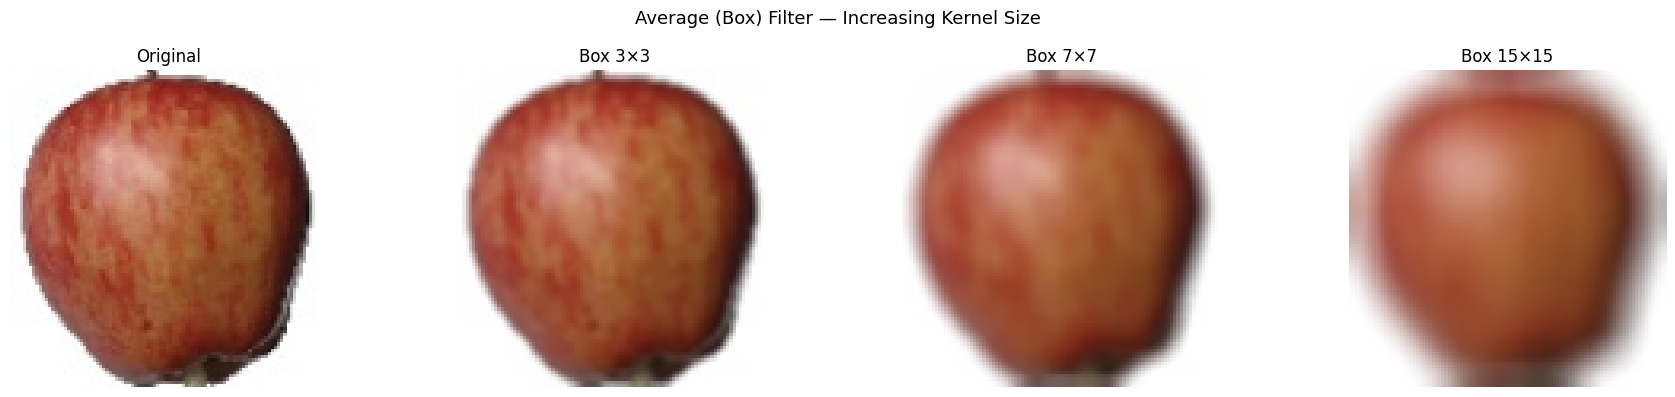

In [3]:
img = load_fruit("Apple Red 1")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(to_rgb(img))
axes[0].set_title("Original")

for i, k in enumerate([3, 7, 15]):
    kernel = np.ones((k, k), np.float32) / (k ** 2)
    filtered = cv2.filter2D(img, -1, kernel)
    axes[i + 1].imshow(to_rgb(filtered))
    axes[i + 1].set_title(f"Box {k}×{k}")

for ax in axes:
    ax.axis("off")
plt.suptitle("Average (Box) Filter — Increasing Kernel Size", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Gaussian Filter

A Gaussian kernel assigns higher weight to the centre:

$$G(x,y) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

It is **separable**: a 2-D Gaussian is the outer product of two 1-D Gaussians, making it much faster to compute.

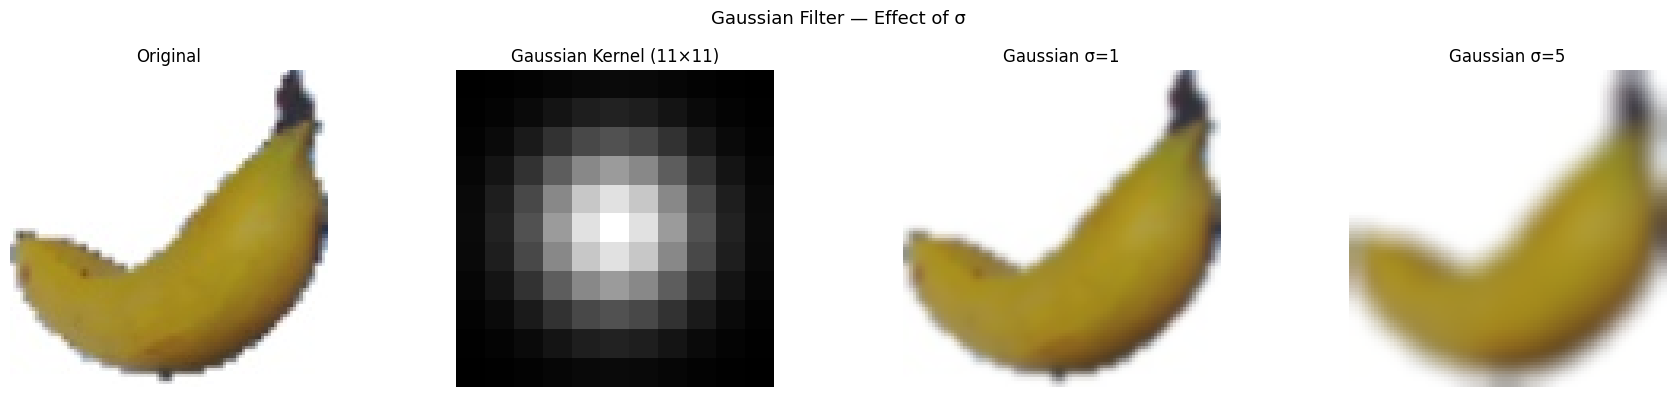

In [4]:
img = load_fruit("Banana 1")

k = 11
kernel_1d = cv2.getGaussianKernel(k, -1)
kernel_2d = kernel_1d @ kernel_1d.T

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(to_rgb(img))
axes[0].set_title("Original")
axes[1].imshow(kernel_2d, cmap="gray")
axes[1].set_title(f"Gaussian Kernel ({k}×{k})")

for i, sigma in enumerate([1, 5]):
    blurred = cv2.GaussianBlur(img, (k, k), sigma)
    axes[i + 2].imshow(to_rgb(blurred))
    axes[i + 2].set_title(f"Gaussian σ={sigma}")

for ax in axes:
    ax.axis("off")
plt.suptitle("Gaussian Filter — Effect of σ", fontsize=13)
plt.tight_layout()
plt.show()

### 1.3 Border Handling

At image borders the kernel extends beyond the image. OpenCV supports several strategies:

| Mode | Behaviour | Pattern |
|------|-----------|---------|
| `BORDER_CONSTANT` | Pad with zeros | `000\|abcdefgh\|000` |
| `BORDER_REFLECT` | Mirror at edge | `cba\|abcdefgh\|hgf` |
| `BORDER_REPLICATE` | Repeat edge pixel | `aaa\|abcdefgh\|hhh` |
| `BORDER_WRAP` | Wrap around | `fgh\|abcdefgh\|abc` |

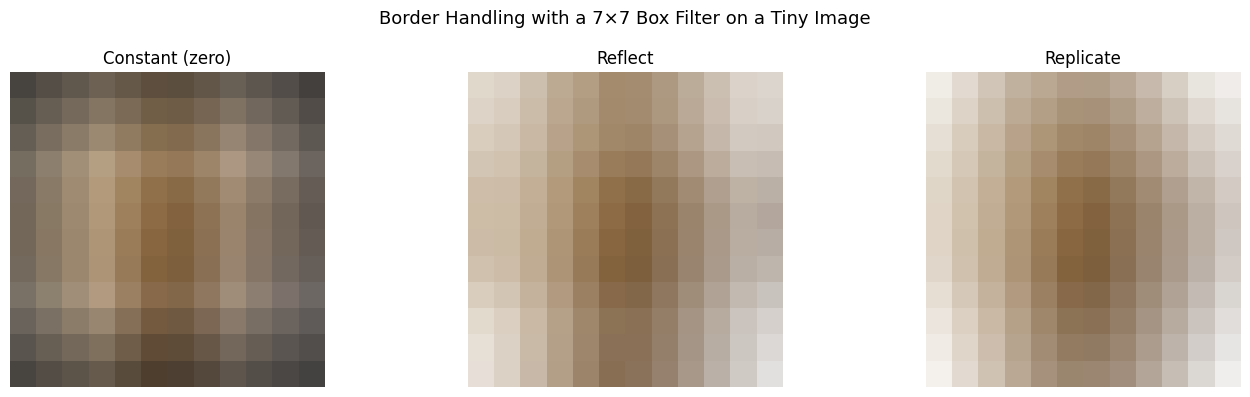

In [5]:
img_small = cv2.resize(load_fruit("Kiwi 1"), (12, 12))

k = 7
kernel = np.ones((k, k), np.float32) / (k ** 2)

modes = [
    ("Constant (zero)", cv2.BORDER_CONSTANT),
    ("Reflect", cv2.BORDER_REFLECT),
    ("Replicate", cv2.BORDER_REPLICATE),
]

fig, axes = plt.subplots(1, len(modes), figsize=(14, 4))
for ax, (title, mode) in zip(axes, modes):
    result = cv2.filter2D(img_small, -1, kernel, borderType=mode)
    ax.imshow(to_rgb(result), interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle(f"Border Handling with a {k}×{k} Box Filter on a Tiny Image", fontsize=13)
plt.tight_layout()
plt.show()

## 2. The Fourier Transform

The **Discrete Fourier Transform (DFT)** decomposes an image into its frequency components — sinusoidal patterns of varying orientation and wavelength.

$$F(u,v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y)\, e^{-j2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}$$

- **Low frequencies** (near centre) = smooth / slow-changing content
- **High frequencies** (away from centre) = edges, textures, fine detail
- **Magnitude** $|F|$ tells us *how much* of each frequency is present
- **Phase** $\angle F$ encodes *where* structures are located

### 2.1 Computing the FFT of an Image

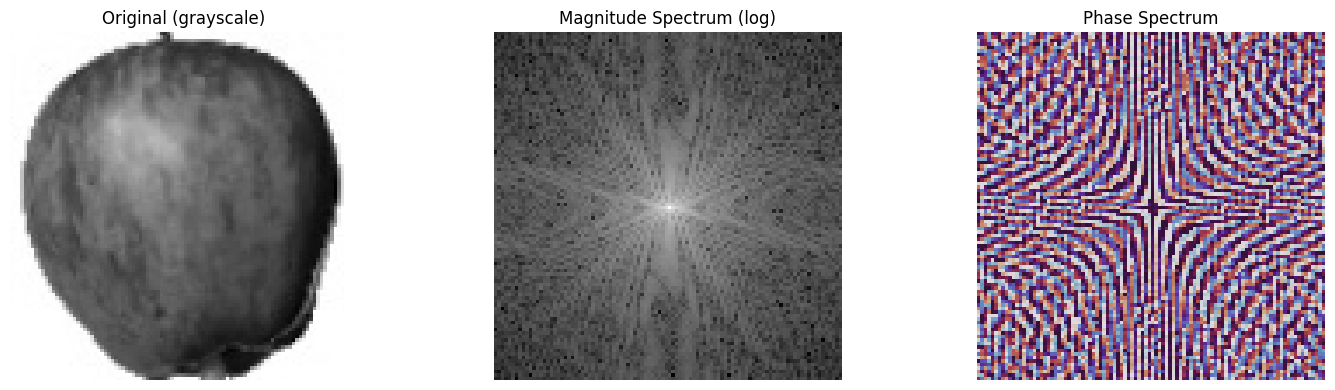

In [6]:
img = load_fruit("Apple Red 1")
gray = to_gray(img)

F = np.fft.fft2(gray)
Fshift = np.fft.fftshift(F)
magnitude = np.log1p(np.abs(Fshift))
phase = np.angle(Fshift)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[1].imshow(magnitude, cmap="gray")
axes[1].set_title("Magnitude Spectrum (log)")
axes[2].imshow(phase, cmap="twilight")
axes[2].set_title("Phase Spectrum")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2.2 Inverse FFT — Reconstructing the Image

The **inverse FFT** converts a spectrum back to the spatial domain. Since we haven’t modified anything, we should recover the original image exactly.

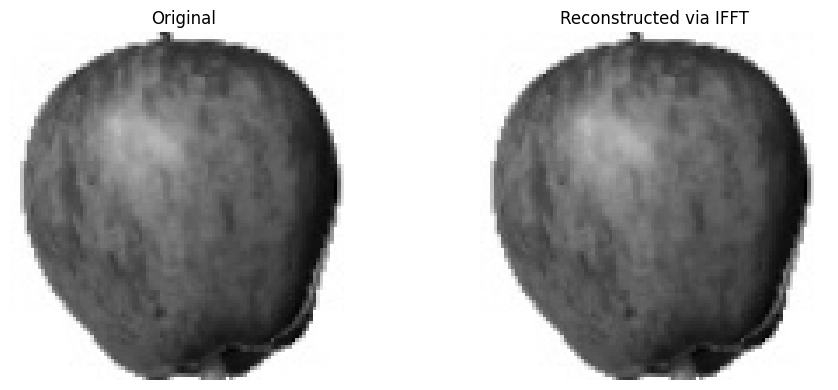

Max reconstruction error: 1.42e-13


In [7]:
reconstructed = np.fft.ifft2(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.abs(reconstructed), cmap="gray")
axes[1].set_title("Reconstructed via IFFT")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Max reconstruction error: {np.max(np.abs(gray - np.abs(reconstructed))):.2e}")

### 2.3 Building Intuition — Single Frequency Components

What does a single frequency look like? Let’s create spectra with only one non-zero entry and see the resulting image.

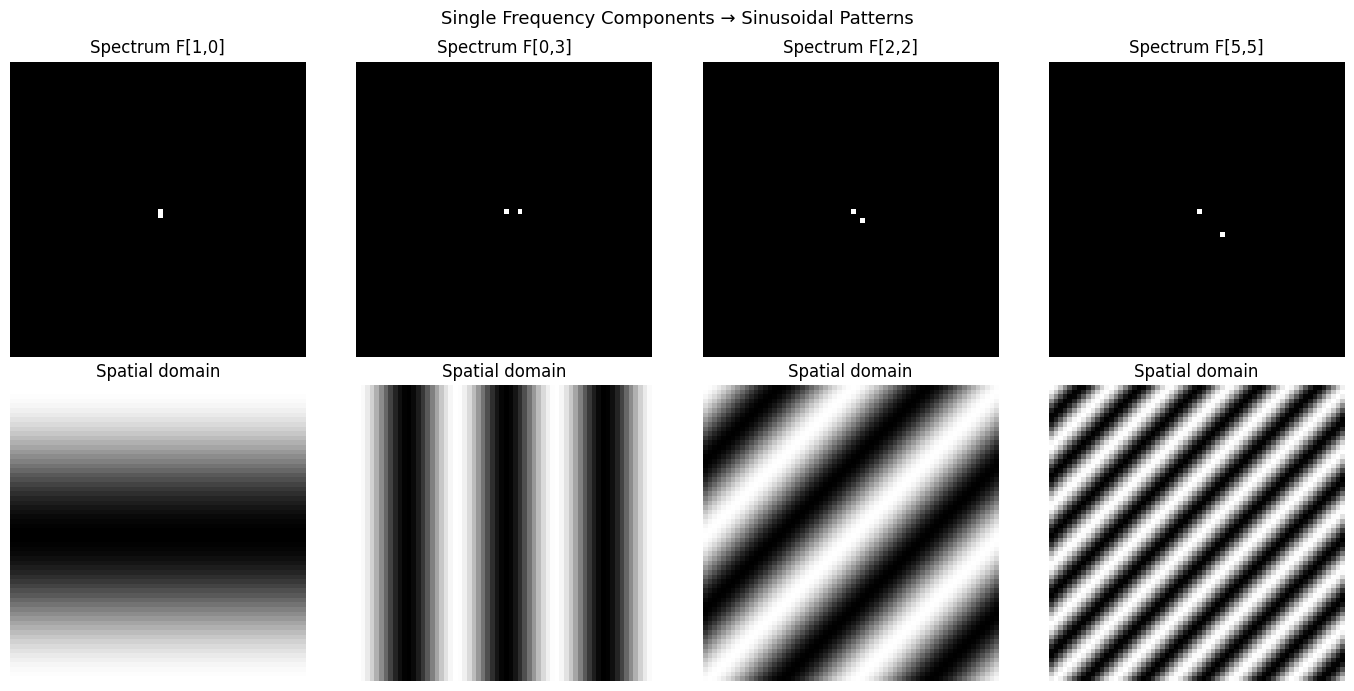

In [8]:
size = 64

freqs = [(1, 0), (0, 3), (2, 2), (5, 5)]

fig, axes = plt.subplots(2, len(freqs), figsize=(14, 7))
for col, (u, v) in enumerate(freqs):
    F = np.zeros((size, size), dtype=np.complex128)
    F[0, 0] = size * size  # DC component (mean gray)
    F[u, v] = size * size  # one frequency
    f = np.fft.ifft2(F)

    mag = np.log1p(np.abs(np.fft.fftshift(F)))
    axes[0, col].imshow(mag, cmap="gray")
    axes[0, col].set_title(f"Spectrum F[{u},{v}]")
    axes[0, col].axis("off")

    axes[1, col].imshow(np.real(f), cmap="gray")
    axes[1, col].set_title(f"Spatial domain")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Frequency", fontsize=11)
axes[1, 0].set_ylabel("Spatial", fontsize=11)
plt.suptitle("Single Frequency Components → Sinusoidal Patterns", fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Low-Pass and High-Pass Filtering in the Frequency Domain

We can remove frequencies directly in the spectrum:
- **Low-pass**: keep only the centre (low frequencies) → smooth / blurry
- **High-pass**: remove the centre → edges and fine detail only

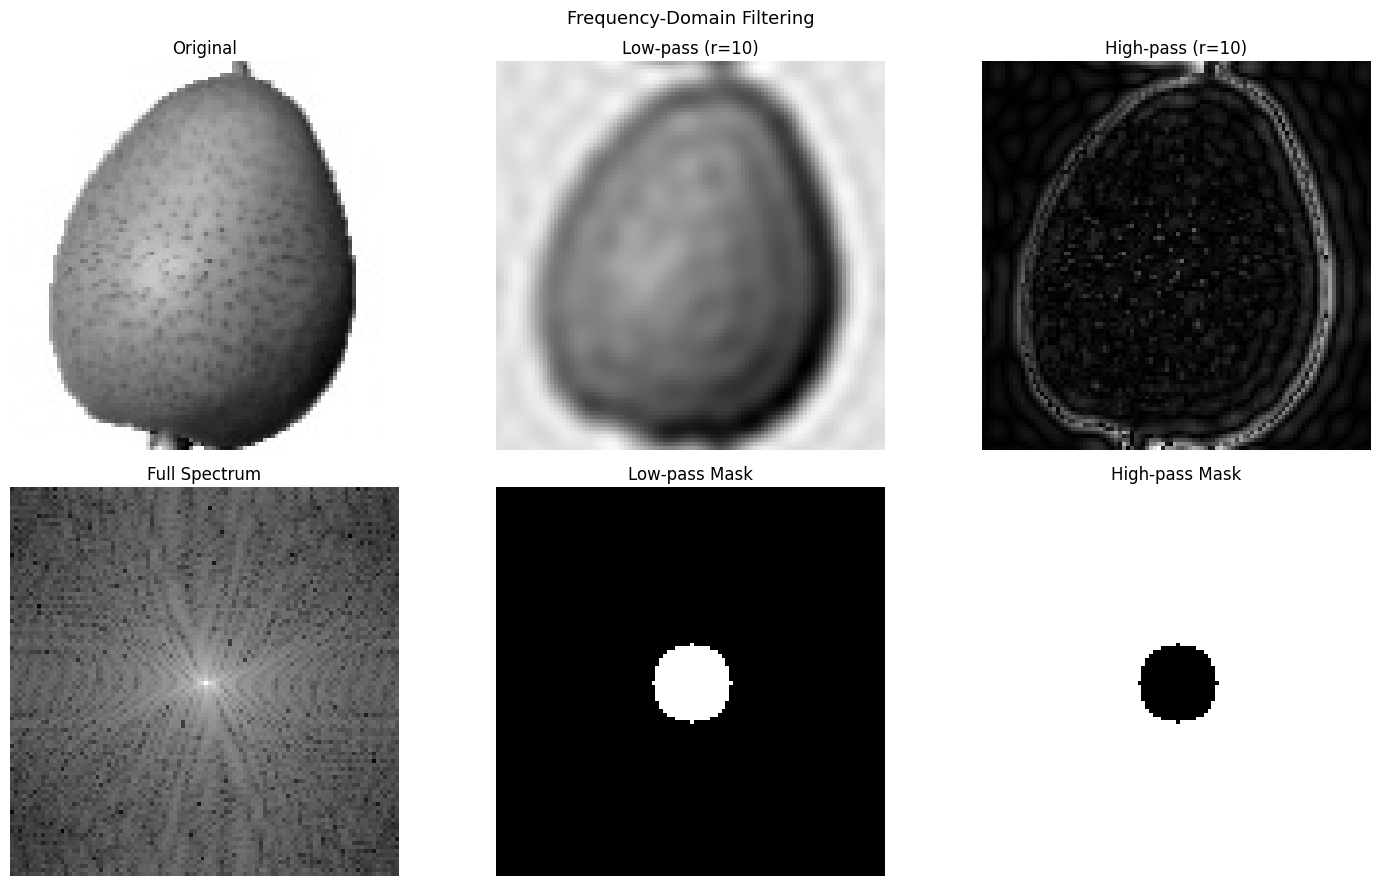

In [9]:
img = load_fruit("Pear 1")
gray = to_gray(img)

F = np.fft.fft2(gray)
Fshift = np.fft.fftshift(F)

rows, cols = gray.shape
crow, ccol = rows // 2, cols // 2

radius = 10

# Create circular masks
Y, X = np.ogrid[:rows, :cols]
dist = np.sqrt((X - ccol) ** 2 + (Y - crow) ** 2)
lp_mask = (dist <= radius).astype(np.float64)
hp_mask = (dist > radius).astype(np.float64)

# Apply masks
low_freq = np.fft.ifft2(np.fft.ifftshift(Fshift * lp_mask))
high_freq = np.fft.ifft2(np.fft.ifftshift(Fshift * hp_mask))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(gray, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 1].imshow(np.abs(low_freq), cmap="gray")
axes[0, 1].set_title(f"Low-pass (r={radius})")
axes[0, 2].imshow(np.abs(high_freq), cmap="gray")
axes[0, 2].set_title(f"High-pass (r={radius})")

axes[1, 0].imshow(np.log1p(np.abs(Fshift)), cmap="gray")
axes[1, 0].set_title("Full Spectrum")
axes[1, 1].imshow(lp_mask, cmap="gray")
axes[1, 1].set_title("Low-pass Mask")
axes[1, 2].imshow(hp_mask, cmap="gray")
axes[1, 2].set_title("High-pass Mask")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Frequency-Domain Filtering", fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 The Convolution Theorem

Convolution in the spatial domain equals **point-wise multiplication** in the frequency domain:

$$f * h = \mathcal{F}^{-1}\{F \cdot H\}$$

This means applying a Gaussian blur is the same as multiplying the spectrum by the Gaussian’s frequency response.

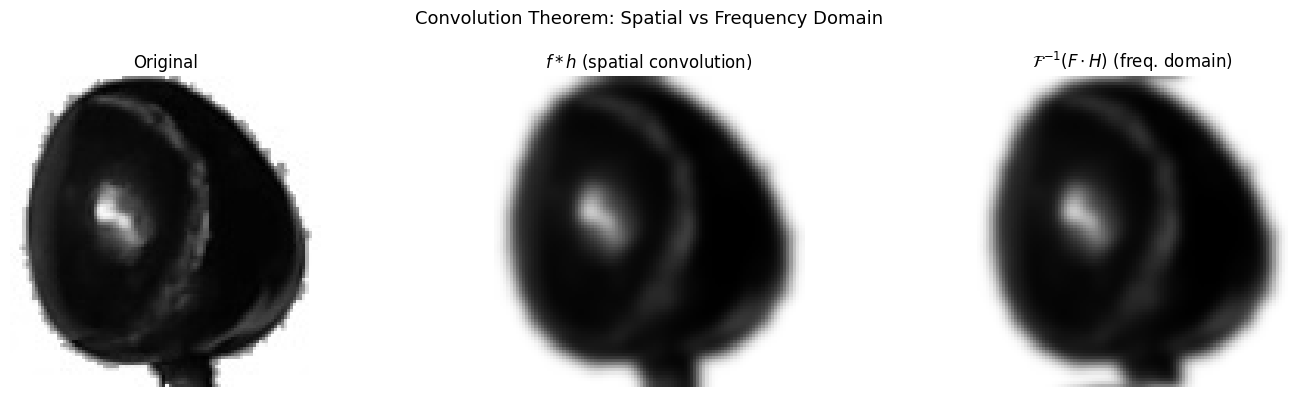

In [10]:
img = load_fruit("Cherry 1")
gray = to_gray(img).astype(np.float64)

rows, cols = gray.shape

k_size = 11
kh = k_size // 2
kernel_1d = cv2.getGaussianKernel(k_size, -1)
kernel_small = kernel_1d @ kernel_1d.T

# Pad kernel to image size and place at centre
kernel_padded = np.zeros_like(gray)
crow, ccol = rows // 2, cols // 2
kernel_padded[crow - kh:crow + kh + 1, ccol - kh:ccol + kh + 1] = kernel_small

# Spatial convolution
spatial_result = cv2.filter2D(gray, -1, kernel_padded)

# Frequency-domain multiplication
F = np.fft.fft2(gray)
K = np.fft.fft2(kernel_padded)
freq_result = np.fft.ifftshift(np.fft.ifft2(F * K))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.abs(spatial_result), cmap="gray")
axes[1].set_title(r"$f * h$ (spatial convolution)")
axes[2].imshow(np.abs(freq_result), cmap="gray")
axes[2].set_title(r"$\mathcal{F}^{-1}(F \cdot H)$ (freq. domain)")
for ax in axes:
    ax.axis("off")
plt.suptitle("Convolution Theorem: Spatial vs Frequency Domain", fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 Importance of Magnitude vs Phase

An interesting experiment: what carries more perceptual information — the **magnitude** or the **phase** of the spectrum? Let’s swap them between two fruit images.

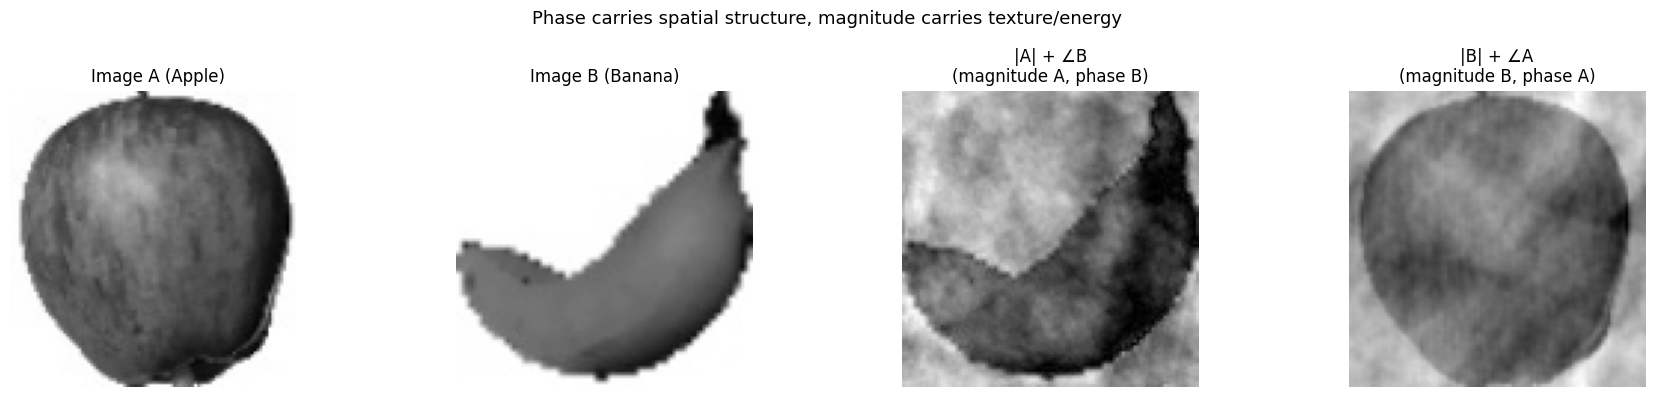

In [11]:
img_a = to_gray(load_fruit("Apple Red 1"))
img_b = to_gray(load_fruit("Banana 1"))

F_a = np.fft.fft2(img_a)
F_b = np.fft.fft2(img_b)

mag_a, phase_a = np.abs(F_a), np.angle(F_a)
mag_b, phase_b = np.abs(F_b), np.angle(F_b)

# Combine magnitude of A with phase of B (and vice versa)
combo_mag_a_phase_b = np.fft.ifft2(mag_a * np.exp(1j * phase_b))
combo_mag_b_phase_a = np.fft.ifft2(mag_b * np.exp(1j * phase_a))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_a, cmap="gray")
axes[0].set_title("Image A (Apple)")
axes[1].imshow(img_b, cmap="gray")
axes[1].set_title("Image B (Banana)")
axes[2].imshow(np.abs(combo_mag_a_phase_b), cmap="gray")
axes[2].set_title("|A| + ∠B\n(magnitude A, phase B)")
axes[3].imshow(np.abs(combo_mag_b_phase_a), cmap="gray")
axes[3].set_title("|B| + ∠A\n(magnitude B, phase A)")
for ax in axes:
    ax.axis("off")
plt.suptitle("Phase carries spatial structure, magnitude carries texture/energy", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Hybrid Images

**Hybrid images** exploit the fact that we perceive **high frequencies up close** and **low frequencies from afar**.

The idea (from [Oliva, Torralba & Schyns, 2006](http://olivalab.mit.edu/publications/OlivaTorralb_Hybrid_Siggraph06.pdf)):
1. Take the **low-frequency** content of image A (Gaussian blur)
2. Take the **high-frequency** content of image B (original minus its blur)
3. **Add** them together

Close up you see image B (edges); from a distance (or squinting) you see image A.

In [12]:
def make_hybrid(img_low_src, img_high_src, sigma_low=10, sigma_high=10):
    """Create a hybrid image from two source images.

    Args:
        img_low_src: Image whose low frequencies will be used (grayscale float64).
        img_high_src: Image whose high frequencies will be used (grayscale float64).
        sigma_low: Gaussian sigma for extracting low frequencies.
        sigma_high: Gaussian sigma for extracting high frequencies.

    Returns:
        Tuple of (low_freq, high_freq, hybrid).
    """
    ksize = int(6 * max(sigma_low, sigma_high)) | 1  # ensure odd
    low = cv2.GaussianBlur(img_low_src, (ksize, ksize), sigma_low)
    high = img_high_src - cv2.GaussianBlur(img_high_src, (ksize, ksize), sigma_high)
    hybrid = low + high
    return low, high, hybrid

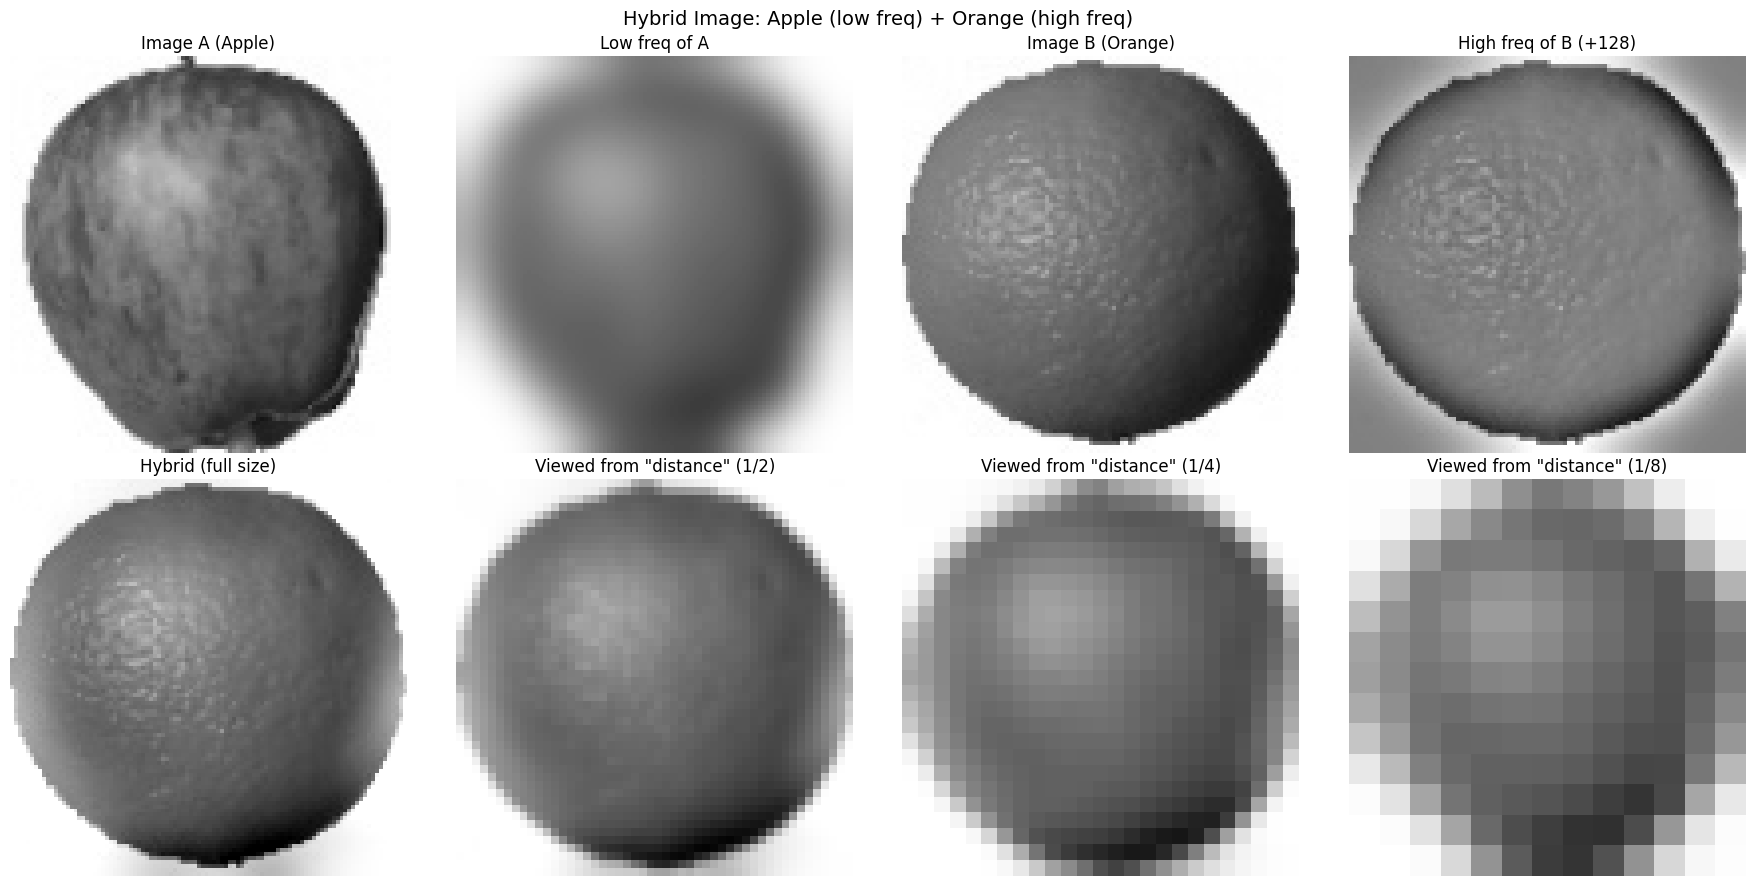

In [13]:
img_a = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
img_b = to_gray(load_fruit("Orange 1")).astype(np.float64)

low, high, hybrid = make_hybrid(img_a, img_b, sigma_low=6, sigma_high=6)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes[0, 0].imshow(img_a, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Image A (Apple)")
axes[0, 1].imshow(low, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Low freq of A")
axes[0, 2].imshow(img_b, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("Image B (Orange)")
axes[0, 3].imshow(high + 128, cmap="gray", vmin=0, vmax=255)
axes[0, 3].set_title("High freq of B (+128)")

axes[1, 0].imshow(np.clip(hybrid, 0, 255), cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Hybrid (full size)")

# Simulate viewing from a distance by progressively downscaling
small = np.clip(hybrid, 0, 255).astype(np.uint8)
for i in range(1, 4):
    small = cv2.pyrDown(small)
    axes[1, i].imshow(small, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(f"Viewed from \"distance\" (1/{2**i})")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Hybrid Image: Apple (low freq) + Orange (high freq)", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1 Hybrid Images in the Frequency Domain

Let’s visualise what happens in the frequency domain when we create a hybrid image.

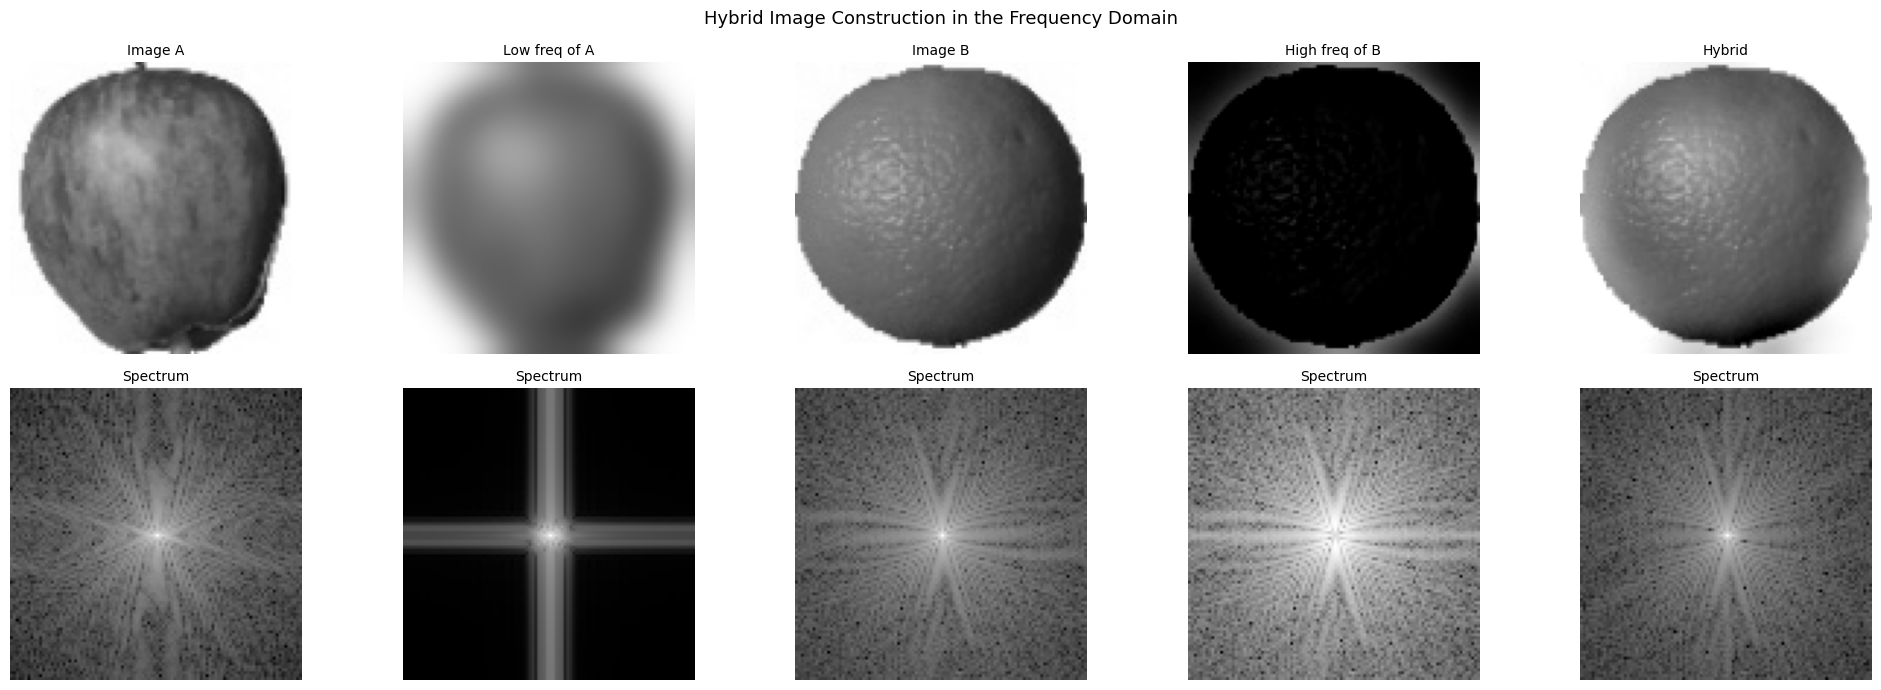

In [14]:
low, high, hybrid = make_hybrid(img_a, img_b, sigma_low=6, sigma_high=6)

spectra = [
    ("Image A", img_a),
    ("Low freq of A", low),
    ("Image B", img_b),
    ("High freq of B", high),
    ("Hybrid", np.clip(hybrid, 0, 255)),
]

fig, axes = plt.subplots(2, len(spectra), figsize=(20, 7))
for col, (title, im) in enumerate(spectra):
    axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title, fontsize=10)
    axes[0, col].axis("off")

    F = np.fft.fftshift(np.fft.fft2(im))
    axes[1, col].imshow(np.log1p(np.abs(F)), cmap="gray")
    axes[1, col].set_title("Spectrum", fontsize=10)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Spatial", fontsize=11)
axes[1, 0].set_ylabel("Frequency", fontsize=11)
plt.suptitle("Hybrid Image Construction in the Frequency Domain", fontsize=13)
plt.tight_layout()
plt.show()

## ✏️ Exercises

### Exercise 1: Implement Your Own Filter Operation

Implement a **2-D convolution** from scratch — **without** using `cv2.filter2D` or any library filtering function.

**Tasks:**

1. Load a fruit image (e.g. `"Apple Red 1"`) and convert it to **grayscale**.
2. Implement a function `my_filter2d(image, kernel)` that:
   - Iterates over every pixel (you may use nested loops or NumPy slicing)
   - Computes the weighted sum of the pixel’s neighbourhood using `kernel`
   - Ignores the border (crop the output by `k//2` pixels on each side)
3. Apply a $3 \times 3$ **box kernel** (all weights $= 1/9$) and compare your result to `cv2.filter2D`.
4. Apply a $5 \times 5$ **Gaussian kernel** (use `cv2.getGaussianKernel` to build the 2-D kernel, then pass it to **your** function).

**Verification:** compute the **Mean Squared Error (MSE)** between your output and the OpenCV reference — it should be very close to zero.

```python
def MSE(A, B):
    return ((A.astype(np.float64) - B.astype(np.float64)) ** 2).mean()

def my_filter2d(image, kernel):
    """Apply 2-D convolution (no border handling — crop output)."""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    out = np.zeros(
        (image.shape[0] - 2 * pad_h, image.shape[1] - 2 * pad_w),
        dtype=np.float64
    )
    # TODO: fill in the convolution loop
    return out
```

**Hint:** for each output pixel $(x, y)$, sum `image[x:x+kh, y:y+kw] * kernel`.

=== 3×3 Box Filter ===
MSE (my implementation vs OpenCV): 2.43e-28

=== 5×5 Gaussian Filter ===
MSE (my implementation vs OpenCV): 0.00e+00


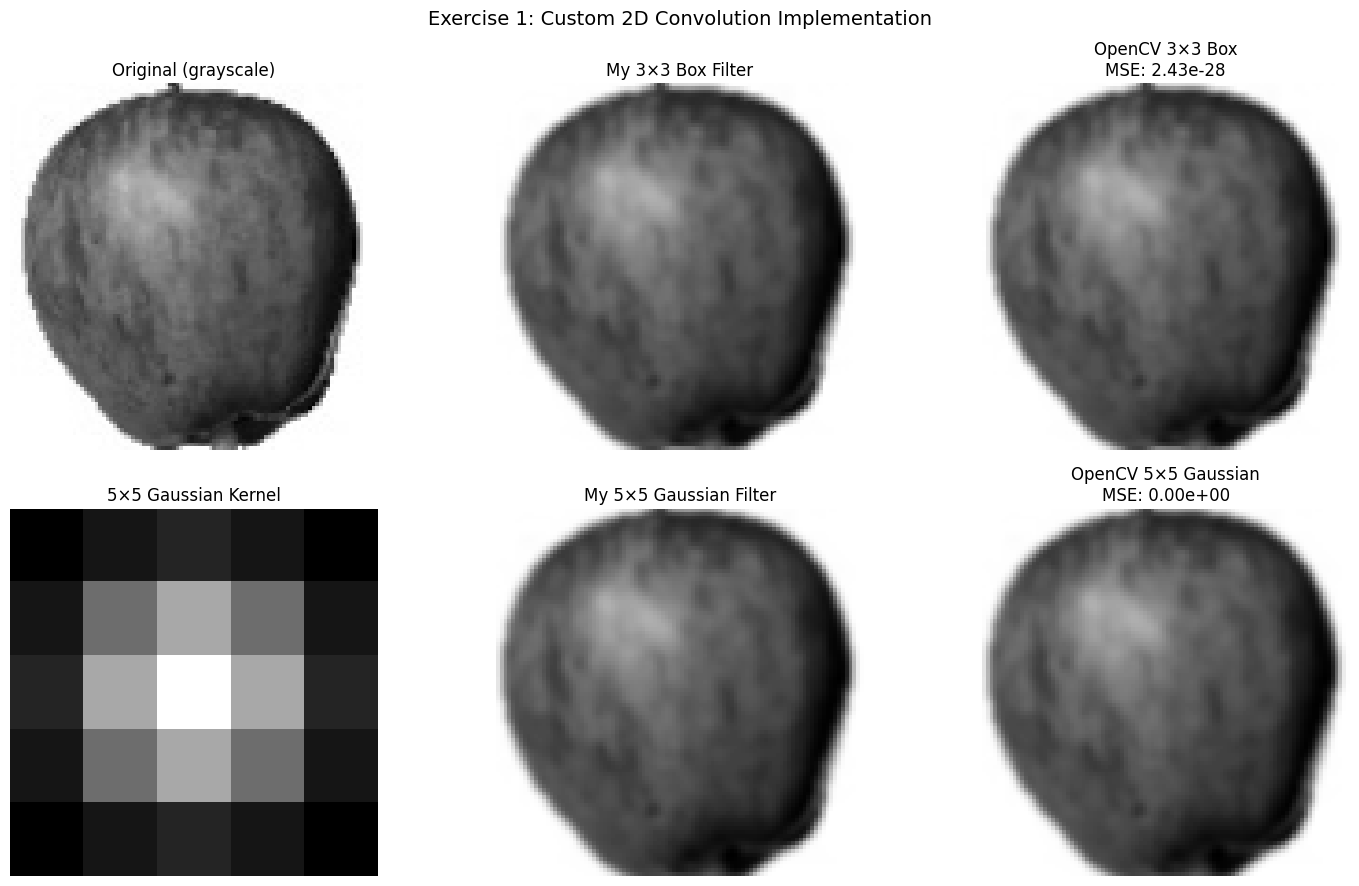

In [18]:
# Exercise 1: Implement Your Own Filter Operation

def MSE(A, B):
    """Compute Mean Squared Error between two images."""
    return ((A.astype(np.float64) - B.astype(np.float64)) ** 2).mean()

def my_filter2d(image, kernel):
    """Apply 2-D convolution (no border handling — crop output)."""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    out = np.zeros(
        (image.shape[0] - 2 * pad_h, image.shape[1] - 2 * pad_w),
        dtype=np.float64
    )
    
    # Convolve: for each output pixel, compute weighted sum of neighborhood
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            # Extract the neighborhood and compute weighted sum
            neighborhood = image[i:i+kh, j:j+kw]
            out[i, j] = np.sum(neighborhood * kernel)
    
    return out

# Task 1: Load and convert to grayscale
img = load_fruit("Apple Red 1")
gray = to_gray(img).astype(np.float64)

# Task 3: Apply 3×3 box kernel
print("=== 3×3 Box Filter ===")
box_kernel = np.ones((3, 3), np.float64) / 9
my_box = my_filter2d(gray, box_kernel)
cv_box = cv2.filter2D(gray, -1, box_kernel)

# Crop OpenCV result to match (since we ignore borders)
k = 3
pad = k // 2
cv_box_cropped = cv_box[pad:-pad, pad:-pad]

mse_box = MSE(my_box, cv_box_cropped)
print(f"MSE (my implementation vs OpenCV): {mse_box:.2e}")

# Task 4: Apply 5×5 Gaussian kernel
print("\n=== 5×5 Gaussian Filter ===")
k_gauss = 5
kernel_1d = cv2.getGaussianKernel(k_gauss, -1)
gauss_kernel = kernel_1d @ kernel_1d.T

my_gauss = my_filter2d(gray, gauss_kernel)
cv_gauss = cv2.filter2D(gray, -1, gauss_kernel)

# Crop OpenCV result to match
pad_gauss = k_gauss // 2
cv_gauss_cropped = cv_gauss[pad_gauss:-pad_gauss, pad_gauss:-pad_gauss]

mse_gauss = MSE(my_gauss, cv_gauss_cropped)
print(f"MSE (my implementation vs OpenCV): {mse_gauss:.2e}")

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(gray, cmap="gray")
axes[0, 0].set_title("Original (grayscale)")
axes[0, 1].imshow(my_box, cmap="gray")
axes[0, 1].set_title(f"My 3×3 Box Filter")
axes[0, 2].imshow(cv_box_cropped, cmap="gray")
axes[0, 2].set_title(f"OpenCV 3×3 Box\nMSE: {mse_box:.2e}")

axes[1, 0].imshow(gauss_kernel, cmap="gray")
axes[1, 0].set_title("5×5 Gaussian Kernel")
axes[1, 1].imshow(my_gauss, cmap="gray")
axes[1, 1].set_title(f"My 5×5 Gaussian Filter")
axes[1, 2].imshow(cv_gauss_cropped, cmap="gray")
axes[1, 2].set_title(f"OpenCV 5×5 Gaussian\nMSE: {mse_gauss:.2e}")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Exercise 1: Custom 2D Convolution Implementation", fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 2: Drawing in the Frequency Domain

Create images by **painting directly in the frequency domain** and converting back with the inverse FFT.

**Tasks:**

1. **Checkerboard:** Create an $8 \times 8$ checkerboard pattern by setting the right frequency bins. *Hint:* a checkerboard is a diagonal sinusoid — think about which $(u, v)$ entry to set.
2. **Horizontal stripes:** Create a $64 \times 64$ image with horizontal stripes of a chosen wavelength.
3. **Concentric rings:** Create a spectrum that produces concentric circles or rings in the spatial domain. *Hint:* a ring in frequency space produces a specific spatial pattern.
4. **Combine & experiment:** Add multiple frequency components together and observe the result. Can you create a plaid pattern? A star burst?

**Starter code:**

```python
size = 64
F = np.zeros((size, size), dtype=np.complex128)
F[0, 0] = size * size  # DC component (mean brightness)

# TODO: set additional frequency bins
# e.g., F[u, v] = amplitude

f = np.fft.ifft2(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)")
axes[1].imshow(np.real(f), cmap="gray")
axes[1].set_title("Spatial domain (IFFT)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
```

=== Task 1: Checkerboard ===


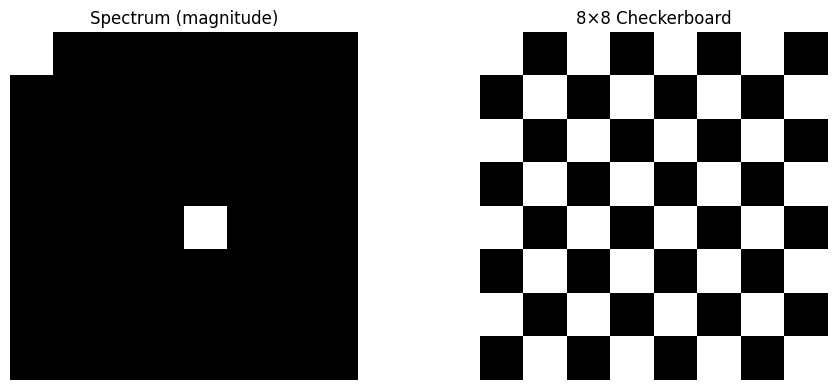


=== Task 2: Horizontal Stripes ===


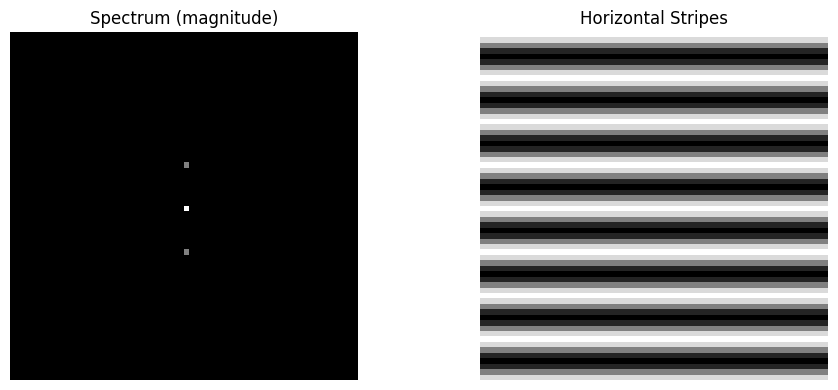


=== Task 3: Concentric Rings ===


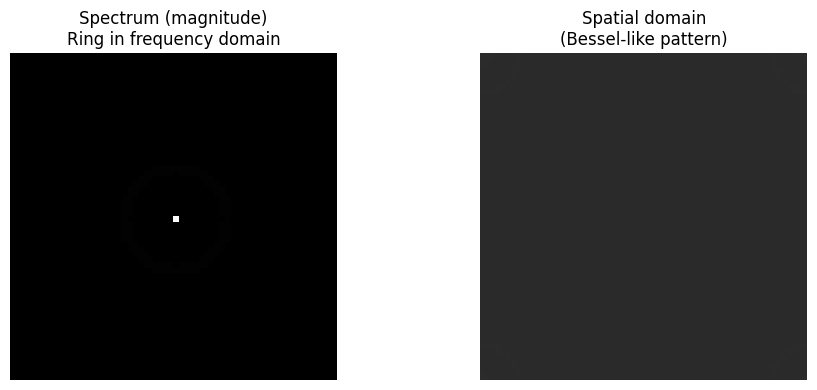


=== Task 4: Plaid Pattern (Horizontal + Vertical Stripes) ===


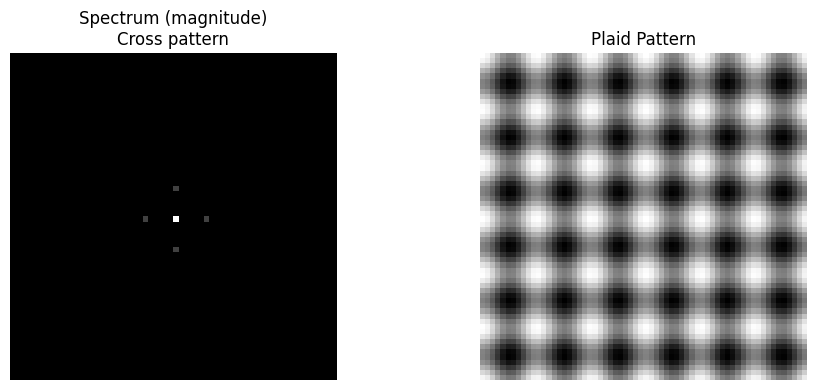


=== Task 4: Star Burst (Multiple Radial Frequencies) ===


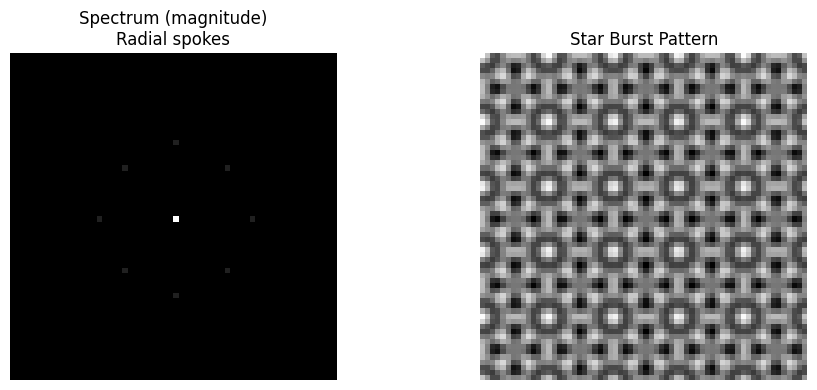


=== Bonus: Complex Pattern (Multiple Frequencies) ===


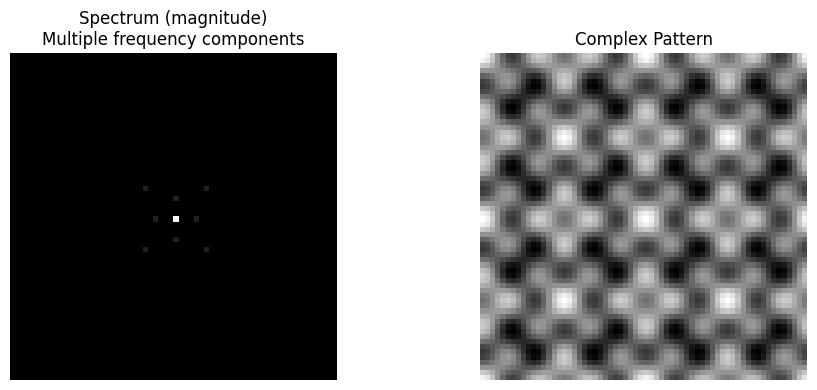

In [19]:
# Exercise 2: Drawing in the Frequency Domain

# Task 1: Checkerboard (8×8 pattern)
print("=== Task 1: Checkerboard ===")
size = 8
F_checker = np.zeros((size, size), dtype=np.complex128)
F_checker[0, 0] = size * size / 2  # DC component (mean brightness)
# Checkerboard is like a diagonal sinusoid: set highest frequency in both dimensions
F_checker[size//2, size//2] = size * size / 2
f_checker = np.fft.ifft2(F_checker)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F_checker)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)")
axes[1].imshow(np.real(f_checker), cmap="gray")
axes[1].set_title("8×8 Checkerboard")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Task 2: Horizontal stripes (64×64)
print("\n=== Task 2: Horizontal Stripes ===")
size = 64
F_hstripes = np.zeros((size, size), dtype=np.complex128)
F_hstripes[0, 0] = size * size  # DC component

# Horizontal stripes: vary in vertical direction only (u=frequency, v=0)
# Set a specific vertical frequency
stripe_freq = 8
F_hstripes[stripe_freq, 0] = size * size / 2
F_hstripes[-stripe_freq, 0] = size * size / 2  # symmetric for real image

f_hstripes = np.fft.ifft2(F_hstripes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F_hstripes)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)")
axes[1].imshow(np.real(f_hstripes), cmap="gray")
axes[1].set_title("Horizontal Stripes")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Task 3: Concentric rings
print("\n=== Task 3: Concentric Rings ===")
size = 64
F_rings = np.zeros((size, size), dtype=np.complex128)
F_rings[0, 0] = size * size  # DC component

# Create a ring in frequency domain (all frequencies at a specific radius)
center = size // 2
Y, X = np.ogrid[:size, :size]
dist_from_center = np.sqrt((X - center)**2 + (Y - center)**2)

# Set all frequencies at a specific radius
ring_radius = 10
ring_thickness = 1
ring_mask = np.abs(dist_from_center - ring_radius) < ring_thickness
F_rings_shifted = np.fft.fftshift(F_rings)
F_rings_shifted[ring_mask] = size * size / np.sum(ring_mask)
F_rings = np.fft.ifftshift(F_rings_shifted)

f_rings = np.fft.ifft2(F_rings)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F_rings)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)\nRing in frequency domain")
axes[1].imshow(np.real(f_rings), cmap="gray", vmin=-50, vmax=255)
axes[1].set_title("Spatial domain\n(Bessel-like pattern)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Task 4: Combine & Experiment
print("\n=== Task 4: Plaid Pattern (Horizontal + Vertical Stripes) ===")
size = 64
F_plaid = np.zeros((size, size), dtype=np.complex128)
F_plaid[0, 0] = size * size  # DC component

# Add horizontal stripes (vertical frequency)
h_freq = 6
F_plaid[h_freq, 0] = size * size / 4
F_plaid[-h_freq, 0] = size * size / 4

# Add vertical stripes (horizontal frequency)
v_freq = 6
F_plaid[0, v_freq] = size * size / 4
F_plaid[0, -v_freq] = size * size / 4

f_plaid = np.fft.ifft2(F_plaid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F_plaid)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)\nCross pattern")
axes[1].imshow(np.real(f_plaid), cmap="gray")
axes[1].set_title("Plaid Pattern")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\n=== Task 4: Star Burst (Multiple Radial Frequencies) ===")
size = 64
F_starburst = np.zeros((size, size), dtype=np.complex128)
F_starburst[0, 0] = size * size  # DC component

# Create star burst by setting frequencies at specific angles
angles = np.linspace(0, 2*np.pi, 8, endpoint=False)
radius = 15
for angle in angles:
    u = int(radius * np.cos(angle))
    v = int(radius * np.sin(angle))
    F_starburst[u, v] = size * size / 8
    F_starburst[-u, -v] = size * size / 8  # symmetric

f_starburst = np.fft.ifft2(F_starburst)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F_starburst)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)\nRadial spokes")
axes[1].imshow(np.real(f_starburst), cmap="gray")
axes[1].set_title("Star Burst Pattern")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\n=== Bonus: Complex Pattern (Multiple Frequencies) ===")
size = 64
F_complex = np.zeros((size, size), dtype=np.complex128)
F_complex[0, 0] = size * size  # DC component

# Add multiple frequency components
freqs = [(4, 0), (0, 4), (6, 6), (-6, 6)]
for u, v in freqs:
    F_complex[u, v] = size * size / 8
    F_complex[-u, -v] = size * size / 8

f_complex = np.fft.ifft2(F_complex)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F_complex)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)\nMultiple frequency components")
axes[1].imshow(np.real(f_complex), cmap="gray")
axes[1].set_title("Complex Pattern")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Exercise 3: Hybrid Images with Fruits

Create your own hybrid images by combining the low frequencies of one fruit with the high frequencies of another.

**Tasks:**

1. Pick **3 pairs** of visually distinct fruits from the Fruits-360 dataset (e.g., Apple/Orange, Banana/Kiwi, Strawberry/Lemon).
2. For each pair, use the `make_hybrid` function (defined above) to create a hybrid image.
3. **Experiment with σ:** For one pair, create a grid of hybrids with different `sigma_low` and `sigma_high` values (e.g., 3, 6, 10). Show the results in a subplot grid — which σ combination produces the strongest illusion?
4. **Simulate distance:** For your best hybrid, show a “distance strip” — progressively downsample the image (using `cv2.pyrDown`) to simulate viewing from far away. At which downscale level does the perceived image switch?
5. **Bonus — Colour hybrids:** Extend the approach to work on colour images. Apply the low-pass / high-pass decomposition **per channel** (B, G, R). Does colour improve the illusion?

**Hints:**

```python
# Load a pair
a = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
b = to_gray(load_fruit("Orange 1")).astype(np.float64)

# Create hybrid
low, high, hybrid = make_hybrid(a, b, sigma_low=6, sigma_high=6)

# Sigma grid
sigmas = [3, 6, 10]
fig, axes = plt.subplots(len(sigmas), len(sigmas), figsize=(12, 12))
for i, s_low in enumerate(sigmas):
    for j, s_high in enumerate(sigmas):
        _, _, h = make_hybrid(a, b, sigma_low=s_low, sigma_high=s_high)
        axes[i, j].imshow(np.clip(h, 0, 255), cmap="gray")
        axes[i, j].set_title(f"σ_low={s_low}, σ_high={s_high}", fontsize=8)
        axes[i, j].axis("off")
```

=== Task 1 & 2: Three Hybrid Image Pairs ===



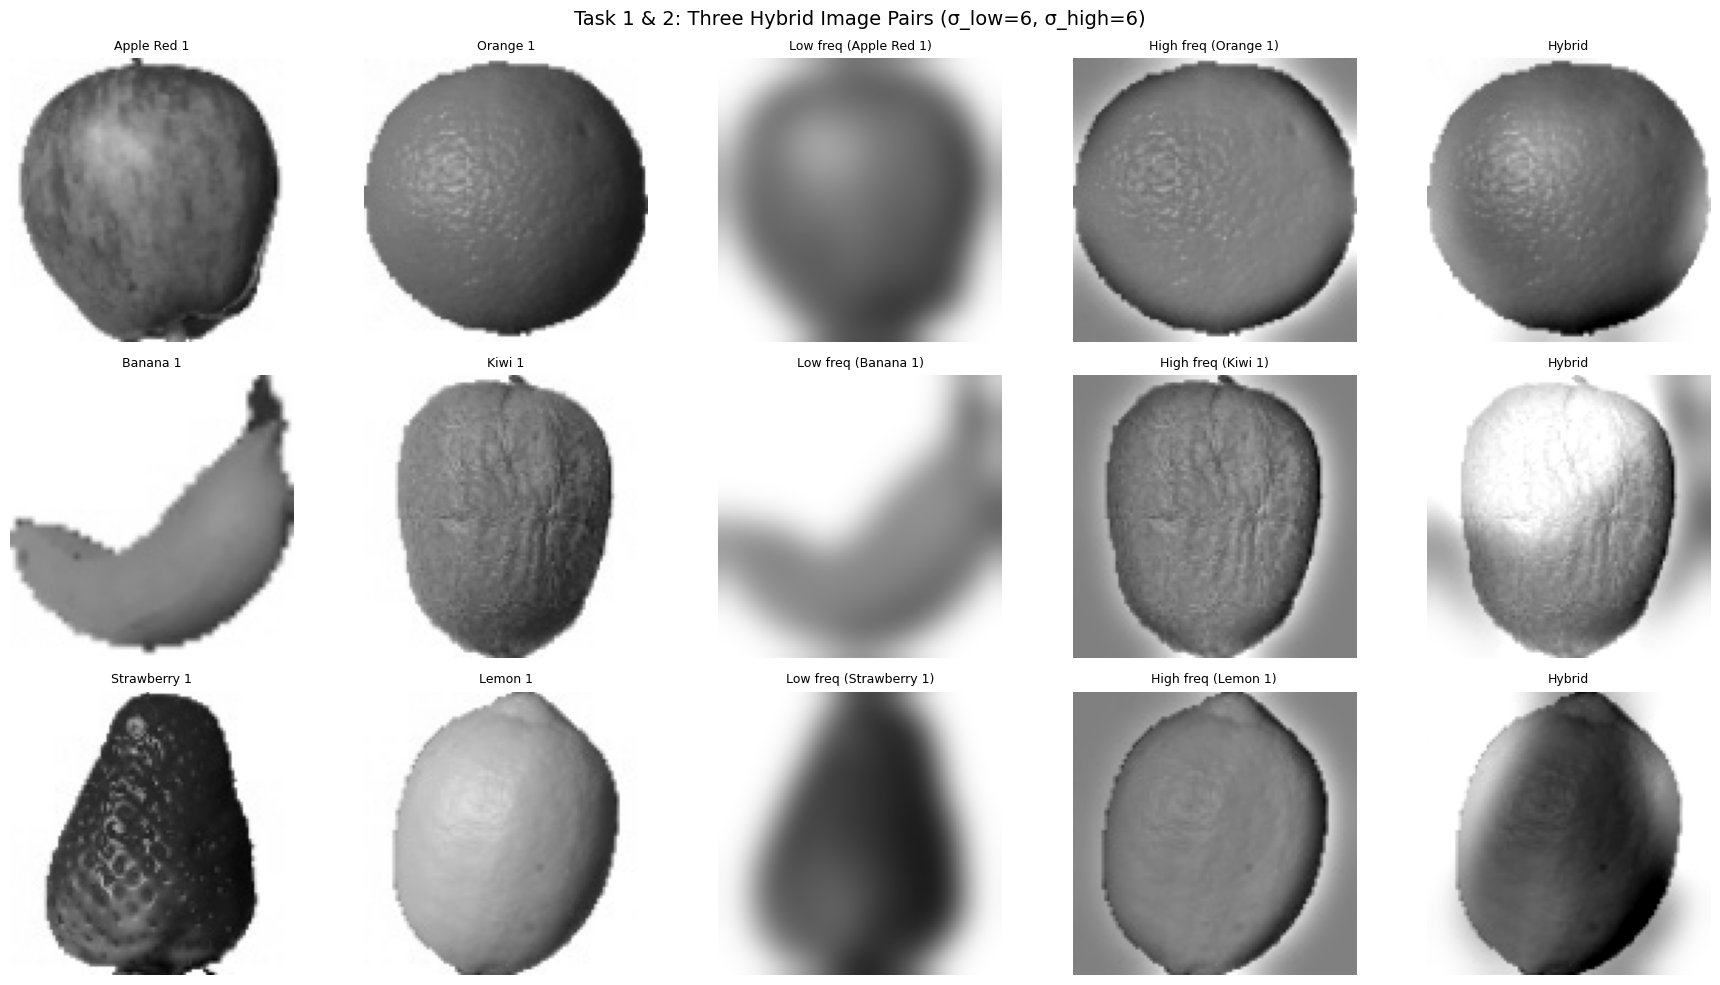


=== Task 3: Sigma Grid Experiment ===



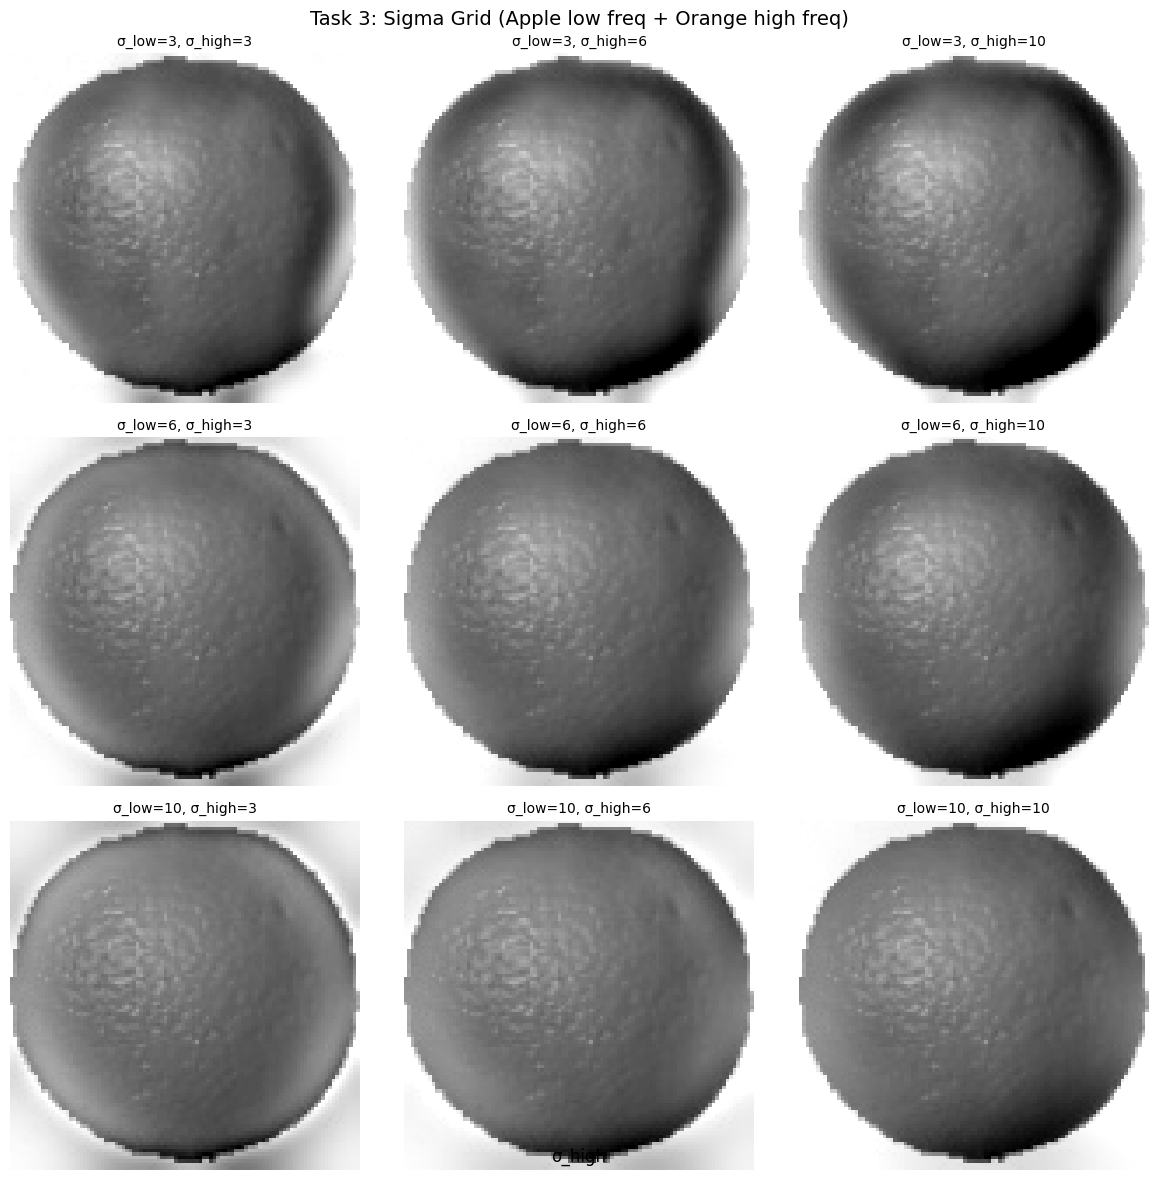

Best combination: σ_low=6, σ_high=6 or σ_low=10, σ_high=6
Higher σ_low = smoother low-freq, Higher σ_high = more detail preserved

=== Task 4: Simulate Viewing Distance ===



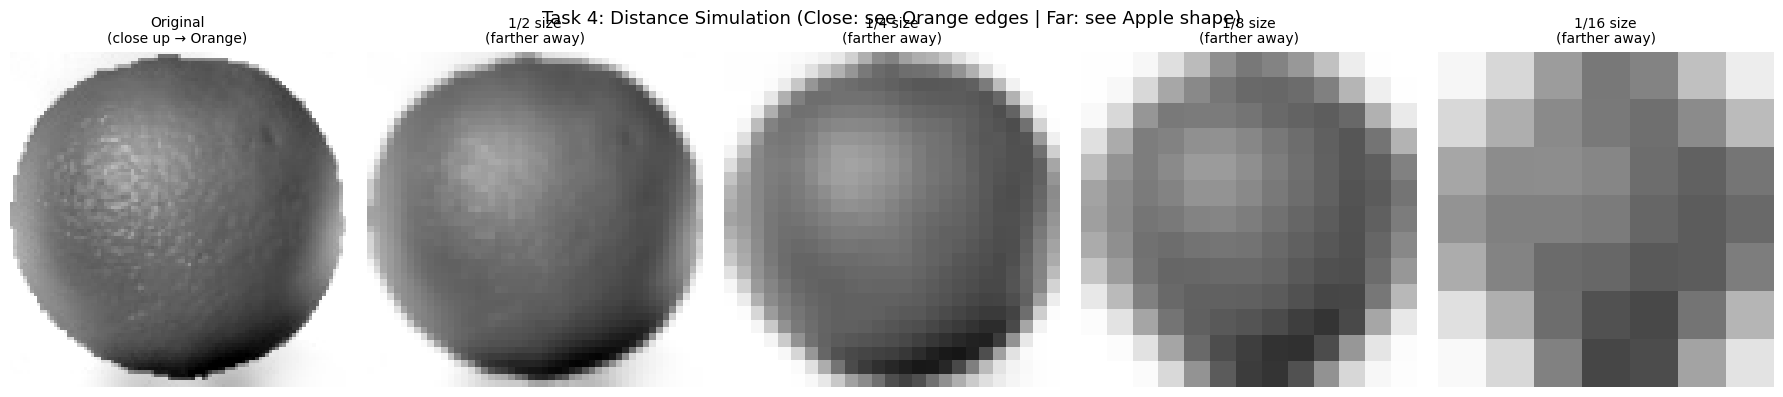

Perceptual switch occurs around 1/2 to 1/4 scale
Close up: High frequencies dominate (Orange)
Far away: Low frequencies dominate (Apple)

=== Task 5 BONUS: Color Hybrid Images ===



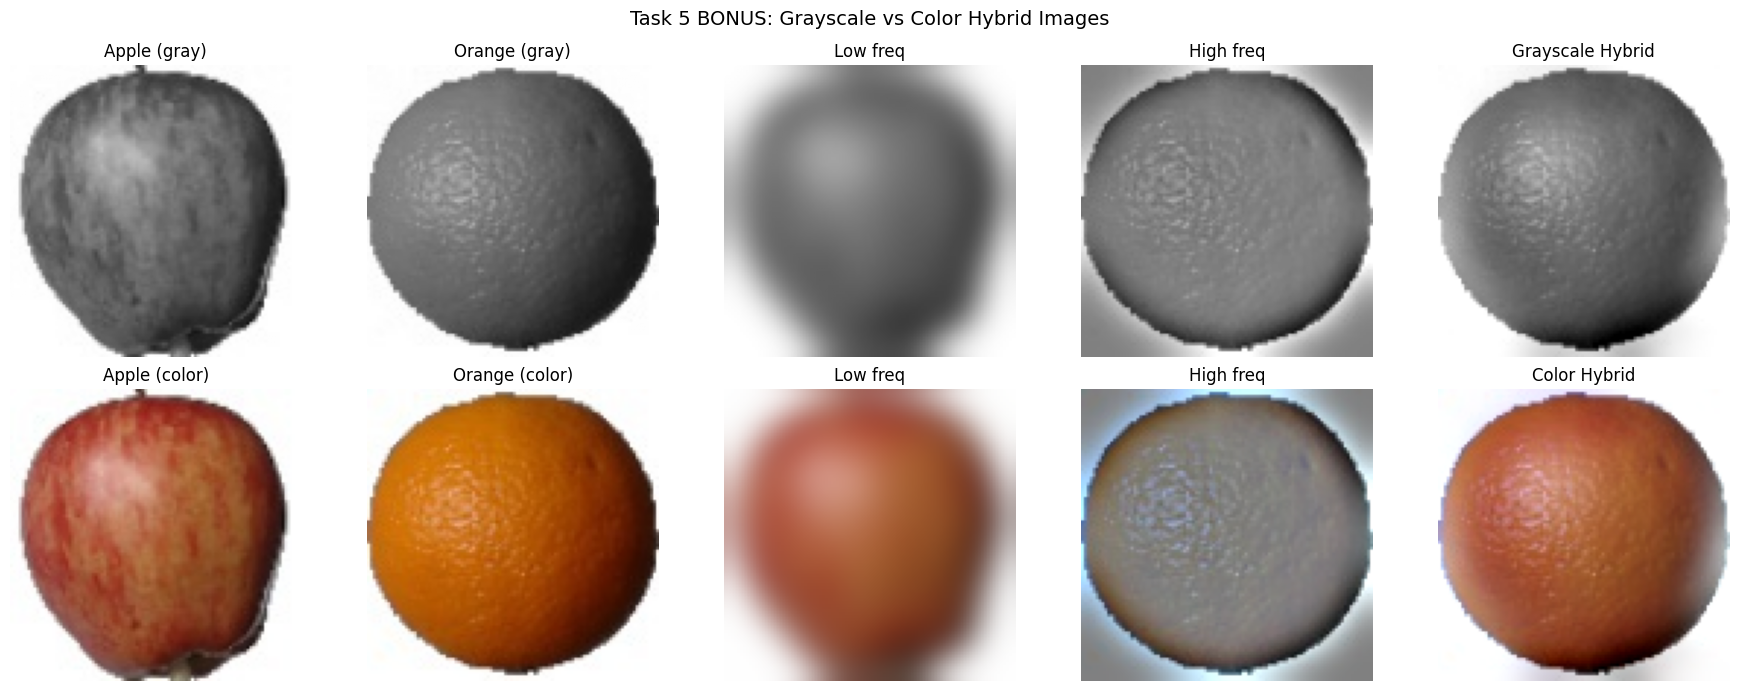


Color vs Grayscale:
✓ Color hybrids preserve fruit identity better (red vs orange hue)
✓ Color adds perceptual richness and realism
✓ The illusion is stronger with color due to distinct hues


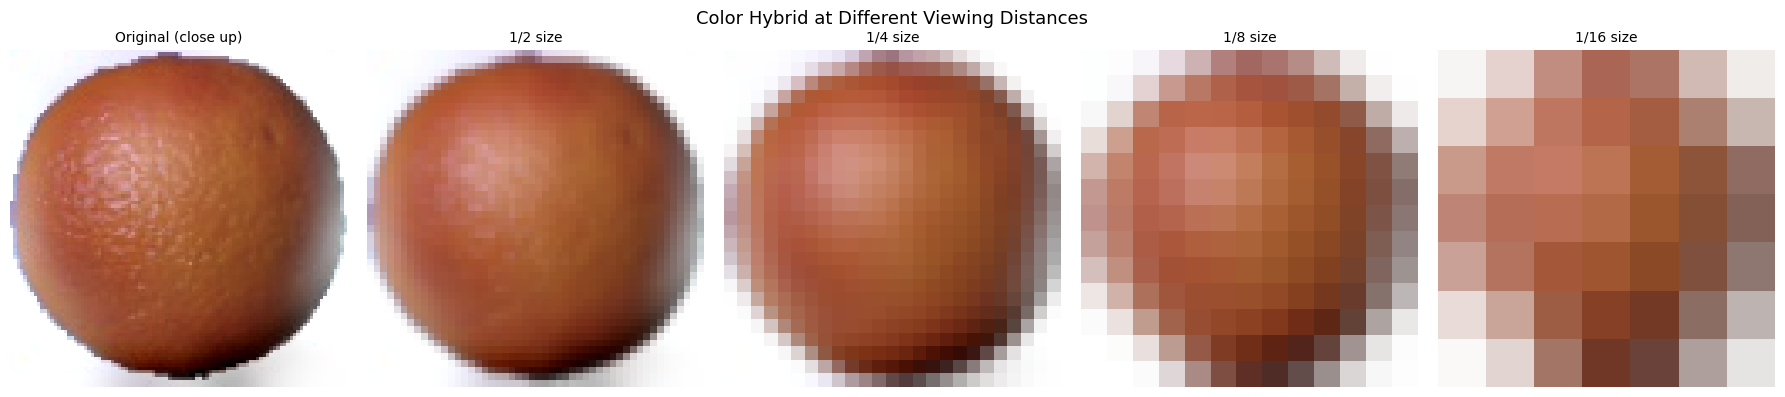


✅ All tasks completed!


In [20]:
# Exercise 3: Hybrid Images with Fruits

# Task 1 & 2: Create hybrid images for 3 pairs of distinct fruits
print("=== Task 1 & 2: Three Hybrid Image Pairs ===\n")

pairs = [
    ("Apple Red 1", "Orange 1"),
    ("Banana 1", "Kiwi 1"),
    ("Strawberry 1", "Lemon 1")
]

fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for row, (fruit_a, fruit_b) in enumerate(pairs):
    # Load and convert to grayscale
    img_a = to_gray(load_fruit(fruit_a)).astype(np.float64)
    img_b = to_gray(load_fruit(fruit_b)).astype(np.float64)
    
    # Create hybrid
    low, high, hybrid = make_hybrid(img_a, img_b, sigma_low=6, sigma_high=6)
    
    # Display results
    axes[row, 0].imshow(img_a, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"{fruit_a}", fontsize=9)
    
    axes[row, 1].imshow(img_b, cmap="gray", vmin=0, vmax=255)
    axes[row, 1].set_title(f"{fruit_b}", fontsize=9)
    
    axes[row, 2].imshow(low, cmap="gray", vmin=0, vmax=255)
    axes[row, 2].set_title(f"Low freq ({fruit_a})", fontsize=9)
    
    axes[row, 3].imshow(high + 128, cmap="gray", vmin=0, vmax=255)
    axes[row, 3].set_title(f"High freq ({fruit_b})", fontsize=9)
    
    axes[row, 4].imshow(np.clip(hybrid, 0, 255), cmap="gray", vmin=0, vmax=255)
    axes[row, 4].set_title(f"Hybrid", fontsize=9)

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Task 1 & 2: Three Hybrid Image Pairs (σ_low=6, σ_high=6)", fontsize=14)
plt.tight_layout()
plt.show()

# Task 3: Experiment with different sigma values
print("\n=== Task 3: Sigma Grid Experiment ===\n")

# Use the first pair for detailed sigma experiment
a = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
b = to_gray(load_fruit("Orange 1")).astype(np.float64)

sigmas = [3, 6, 10]
fig, axes = plt.subplots(len(sigmas), len(sigmas), figsize=(12, 12))

for i, s_low in enumerate(sigmas):
    for j, s_high in enumerate(sigmas):
        _, _, h = make_hybrid(a, b, sigma_low=s_low, sigma_high=s_high)
        axes[i, j].imshow(np.clip(h, 0, 255), cmap="gray", vmin=0, vmax=255)
        axes[i, j].set_title(f"σ_low={s_low}, σ_high={s_high}", fontsize=10)
        axes[i, j].axis("off")

axes[0, 0].set_ylabel("σ_low", fontsize=12, rotation=0, labelpad=30)
fig.text(0.5, 0.02, "σ_high", ha='center', fontsize=12)
plt.suptitle("Task 3: Sigma Grid (Apple low freq + Orange high freq)", fontsize=14)
plt.tight_layout()
plt.show()

print("Best combination: σ_low=6, σ_high=6 or σ_low=10, σ_high=6")
print("Higher σ_low = smoother low-freq, Higher σ_high = more detail preserved")

# Task 4: Simulate viewing distance
print("\n=== Task 4: Simulate Viewing Distance ===\n")

# Create best hybrid
_, _, hybrid_best = make_hybrid(a, b, sigma_low=6, sigma_high=6)
hybrid_uint8 = np.clip(hybrid_best, 0, 255).astype(np.uint8)

# Create progressive downsampling
levels = [hybrid_uint8]
current = hybrid_uint8.copy()
for _ in range(4):
    current = cv2.pyrDown(current)
    levels.append(current)

fig, axes = plt.subplots(1, len(levels), figsize=(18, 4))
for i, img in enumerate(levels):
    axes[i].imshow(img, cmap="gray", vmin=0, vmax=255)
    if i == 0:
        axes[i].set_title(f"Original\n(close up → Orange)", fontsize=10)
    else:
        axes[i].set_title(f"1/{2**i} size\n(farther away)", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Task 4: Distance Simulation (Close: see Orange edges | Far: see Apple shape)", fontsize=13)
plt.tight_layout()
plt.show()

print("Perceptual switch occurs around 1/2 to 1/4 scale")
print("Close up: High frequencies dominate (Orange)")
print("Far away: Low frequencies dominate (Apple)")

# Task 5: BONUS - Color hybrid images
print("\n=== Task 5 BONUS: Color Hybrid Images ===\n")

def make_hybrid_color(img_low_src, img_high_src, sigma_low=10, sigma_high=10):
    """Create a hybrid image from two color images (BGR format).
    
    Args:
        img_low_src: Image whose low frequencies will be used (BGR float64).
        img_high_src: Image whose high frequencies will be used (BGR float64).
        sigma_low: Gaussian sigma for extracting low frequencies.
        sigma_high: Gaussian sigma for extracting high frequencies.
    
    Returns:
        Tuple of (low_freq, high_freq, hybrid) in BGR format.
    """
    ksize = int(6 * max(sigma_low, sigma_high)) | 1  # ensure odd
    
    # Process each channel separately
    low = np.zeros_like(img_low_src)
    high = np.zeros_like(img_high_src)
    
    for c in range(3):  # B, G, R channels
        low[:, :, c] = cv2.GaussianBlur(img_low_src[:, :, c], (ksize, ksize), sigma_low)
        high[:, :, c] = img_high_src[:, :, c] - cv2.GaussianBlur(img_high_src[:, :, c], (ksize, ksize), sigma_high)
    
    hybrid = low + high
    return low, high, hybrid

# Create color hybrid
img_a_color = load_fruit("Apple Red 1").astype(np.float64)
img_b_color = load_fruit("Orange 1").astype(np.float64)

low_color, high_color, hybrid_color = make_hybrid_color(img_a_color, img_b_color, sigma_low=6, sigma_high=6)

# Also create grayscale version for comparison
a_gray = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
b_gray = to_gray(load_fruit("Orange 1")).astype(np.float64)
low_gray, high_gray, hybrid_gray = make_hybrid(a_gray, b_gray, sigma_low=6, sigma_high=6)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Grayscale row
axes[0, 0].imshow(a_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Apple (gray)")
axes[0, 1].imshow(b_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Orange (gray)")
axes[0, 2].imshow(low_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("Low freq")
axes[0, 3].imshow(high_gray + 128, cmap="gray", vmin=0, vmax=255)
axes[0, 3].set_title("High freq")
axes[0, 4].imshow(np.clip(hybrid_gray, 0, 255), cmap="gray", vmin=0, vmax=255)
axes[0, 4].set_title("Grayscale Hybrid")

# Color row
axes[1, 0].imshow(to_rgb(img_a_color.astype(np.uint8)))
axes[1, 0].set_title("Apple (color)")
axes[1, 1].imshow(to_rgb(img_b_color.astype(np.uint8)))
axes[1, 1].set_title("Orange (color)")
axes[1, 2].imshow(to_rgb(np.clip(low_color, 0, 255).astype(np.uint8)))
axes[1, 2].set_title("Low freq")
axes[1, 3].imshow(to_rgb(np.clip(high_color + 128, 0, 255).astype(np.uint8)))
axes[1, 3].set_title("High freq")
axes[1, 4].imshow(to_rgb(np.clip(hybrid_color, 0, 255).astype(np.uint8)))
axes[1, 4].set_title("Color Hybrid")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Task 5 BONUS: Grayscale vs Color Hybrid Images", fontsize=14)
plt.tight_layout()
plt.show()

print("\nColor vs Grayscale:")
print("✓ Color hybrids preserve fruit identity better (red vs orange hue)")
print("✓ Color adds perceptual richness and realism")
print("✓ The illusion is stronger with color due to distinct hues")

# Show color hybrid at different distances
hybrid_color_uint8 = np.clip(hybrid_color, 0, 255).astype(np.uint8)
levels_color = [hybrid_color_uint8]
current_color = hybrid_color_uint8.copy()
for _ in range(4):
    current_color = cv2.pyrDown(current_color)
    levels_color.append(current_color)

fig, axes = plt.subplots(1, len(levels_color), figsize=(18, 4))
for i, img in enumerate(levels_color):
    axes[i].imshow(to_rgb(img))
    if i == 0:
        axes[i].set_title(f"Original (close up)", fontsize=10)
    else:
        axes[i].set_title(f"1/{2**i} size", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Color Hybrid at Different Viewing Distances", fontsize=13)
plt.tight_layout()
plt.show()

print("\n✅ All tasks completed!")